# Supervised Fine-Tuning (SFT) dengan LoRA
## Studi Kasus: Bahasa Daerah Indonesia

**Tujuan:** Fine-tune small language model agar dapat mengikuti instruksi dalam bahasa daerah Indonesia.

**Stack:**
- `transformers` — load model & tokenizer
- `peft` — LoRA implementation
- `trl` — SFTTrainer
- `datasets` — load & process data

> ⚠️ Tidak menggunakan Unsloth atau layanan as-a-service. Semua dibangun dari library standar HuggingFace.
>
> ✅ Pastikan **Runtime → Change runtime type → T4 GPU** sebelum menjalankan.

## 0. Instalasi Dependencies

In [ ]:
# Uninstall dulu untuk menghindari konflik versi
!pip uninstall -y transformers trl peft accelerate bitsandbytes -q

# Install kombinasi versi yang sudah teruji kompatibel satu sama lain
!pip install -q "transformers==4.47.0"
!pip install -q "accelerate==1.1.1"
!pip install -q "peft==0.13.2"
!pip install -q "trl==0.12.0"
!pip install -q datasets bitsandbytes matplotlib

print("✅ Install selesai!")
print("⚠️  WAJIB: Restart runtime sekarang!")
print("   Colab  : Runtime → Restart session")
print("   Jupyter: Kernel → Restart Kernel")
print("   Setelah restart, jalankan mulai dari Cell 1 (JANGAN jalankan Cell 0 lagi)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.3 MB/s eta 0:00:00
✅ Install selesai!
⚠️  WAJIB: Restart runtime sekarang!
   Colab  : Runtime → Restart session
   Jupyter: Kernel → Restart Kernel
   Setelah restart, jalankan mulai dari Cell 1 (JANGAN jalankan Cell 0 lagi)


## 1. Import dan Konfigurasi

In [ ]:
import os
import json
import torch
from dataclasses import dataclass, field
from typing import List, Dict, Optional

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from trl import SFTTrainer, SFTConfig

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  GPU tidak terdeteksi! Aktifkan di Runtime → Change runtime type → T4 GPU")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 2. Konfigurasi Global

Ubah nilai di bawah sesuai pilihan Anda. Tidak perlu menyentuh kode lain.

In [ ]:
# ============================================================
#   KONFIGURASI — ubah sesuai kebutuhan
# ============================================================

# --- Pilihan model (uncomment satu) ---
MODEL_ID = "Qwen/Qwen2.5-0.5B"
# MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # ~1.1B param
# MODEL_ID = "Qwen/Qwen2.5-0.5B"                   # ~0.5B param, performa bagus
# MODEL_ID = "google/gemma-2-2b"                   # ~2B param, butuh akses HF
# MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"    # ~3.8B param, pakai 4-bit

# --- Pilihan dataset ---
DATASET_CHOICE = "cendol"

# --- Direktori output ---
OUTPUT_DIR   = "./output/sft-lora"
ADAPTER_DIR  = "./output/adapter"
MERGED_DIR   = "./output/merged-model"

# --- Hyperparameter pelatihan ---
MAX_SEQ_LEN     = 512
NUM_EPOCHS      = 2
BATCH_SIZE      = 2       # turunkan ke 1 jika OOM
GRAD_ACCUM      = 4       # efektif batch size = BATCH_SIZE * GRAD_ACCUM
LEARNING_RATE   = 2e-4
MAX_TRAIN_SAMPLES = 1000  # None = pakai semua

# --- LoRA hyperparameter ---
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05

# --- Kuantisasi (aktifkan untuk model >=2B di GPU < 8GB) ---
USE_4BIT = False

# Seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
print("✅ Konfigurasi selesai.")

NameError: name 'torch' is not defined

In [ ]:
import torch  # ← tambahkan baris ini di paling atas Cell 2

# ============================================================
#   KONFIGURASI — ubah sesuai kebutuhan
# ============================================================

MODEL_ID = "Qwen/Qwen2.5-0.5B"
DATASET_CHOICE = "cendol"

OUTPUT_DIR   = "./output/sft-lora"
ADAPTER_DIR  = "./output/adapter"
MERGED_DIR   = "./output/merged-model"

MAX_SEQ_LEN       = 512
NUM_EPOCHS        = 2
BATCH_SIZE        = 2
GRAD_ACCUM        = 4
LEARNING_RATE     = 2e-4
MAX_TRAIN_SAMPLES = 1000

LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05

USE_4BIT = False

SEED = 42
torch.manual_seed(SEED)
print("✅ Konfigurasi selesai.")

✅ Konfigurasi selesai.


## 3. Bagian Eksplorasi: Mengapa Base Model Lemah dalam Mengikuti Instruksi?

> **Pertanyaan kunci:** Model yang dilatih pada triliunan token teks internet memiliki pengetahuan luas,
> tapi mengapa gagal menjawab instruksi sederhana?

In [ ]:
# Muat tokenizer dan base model terlebih dahulu
print(f"Memuat model: {MODEL_ID}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Pastikan tokenizer punya pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"EOS token       : {tokenizer.eos_token!r}")
print(f"PAD token       : {tokenizer.pad_token!r}")

Memuat model: Qwen/Qwen2.5-0.5B


NameError: name 'AutoTokenizer' is not defined

In [ ]:
# Konfigurasi kuantisasi (opsional)
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total parameter : {total_params:,} ({total_params/1e6:.1f}M)")

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Total parameter : 361,821,120 (361.8M)


In [ ]:
def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 200) -> str:
    """Helper: generate teks dari prompt."""
    model.eval()
    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # Hanya ambil bagian yang digenerate (bukan prompt)
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)


# ============================================================
#   EKSPLORASI BASE MODEL — amati perilakunya sebelum fine-tuning
# ============================================================
test_prompts = [
    "Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?",
    "Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.",
    "Ceritakan legenda Sangkuriang dari Jawa Barat.",
]

print("=" * 60)
print("RESPONS BASE MODEL (sebelum fine-tuning)")
print("=" * 60)
for prompt in test_prompts:
    print(f"\n[INSTRUKSI]: {prompt}")
    response = generate_text(base_model, tokenizer, prompt)
    print(f"[RESPONS   ]: {response[:300]}")
    print("-" * 60)

print("""
ANALISIS:
Base model dilatih dengan objective 'next token prediction' pada teks mentah.
Ia belajar melanjutkan teks, BUKAN merespons instruksi.
Akibatnya: model cenderung melanjutkan kalimat tanya, bukan menjawabnya.
""")

RESPONS BASE MODEL (sebelum fine-tuning)

[INSTRUKSI]: Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?
[RESPONS   ]: 

Bawana ialah memayu yang dijadikan pada orang lain sebagai tinggi yang menyebabkan kejadian kesetiaan dan penyelidikan, setiap anaknya tidak dapat untuk membaca, mencari, memohon, dan memperkenalkan permainan yang menyebabkan kejadian kepada mereka. Mereka tidak harus melakukan masa dan mengakui s
------------------------------------------------------------

[INSTRUKSI]: Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.
[RESPONS   ]: 

Gudeg di dalam kuriren, dibuat dengan berbagai menunjukan wajah dan pengenalan, dengan berbagai makna untuk berada di sekitar itu. Dalam jenis peranggih, serta yang terdiri dari komoditas terbuka, disampaikan oleh petang. Di bawah bagian atas pengenalan makna di dalam kurir, tersedia adanya halama
------------------------------------------------------------

[INSTRUKSI]: Ceritakan legenda Sangkuriang dari Jawa Barat.
[RESPONS 

## 4. Persiapan Dataset

### Pilihan Dataset Bahasa Daerah Indonesia

| Dataset | HuggingFace ID | Bahasa | Format |
|---------|---------------|--------|--------|
| **Cendol Collection v2** | `indonlp/cendol_collection_v2` | 10+ regional | instruction-output |
| **Bryandts Instruct** | `bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi` | 9 bahasa | instruction-input-output |
| **NusaX-MT** | `indonlp/NusaX-MT` | 12 bahasa | parallel translation |

> **Rekomendasi:** Gunakan `bryandts/...` atau `indonlp/cendol_collection_v2` untuk SFT langsung.

In [ ]:
# ============================================================
#   DATASET SINTETIS BAHASA DAERAH (built-in, tanpa download)
#   Gunakan ini jika tidak ada koneksi internet
# ============================================================

SYNTHETIC_DATA = [
    # --- Adat & Tradisi Jawa ---
    {
        "instruction": "Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?",
        "input": "",
        "output": "Memayu Hayuning Bawana adalah filosofi Jawa yang berarti 'memperindah keindahan dunia'. Filosofi ini mengajarkan bahwa setiap manusia memiliki tanggung jawab untuk menjaga keselarasan, keharmonisan, dan keindahan alam semesta. Manusia tidak hanya hidup untuk dirinya sendiri, tetapi juga untuk merawat bumi dan sesama makhluk hidup."
    },
    {
        "instruction": "Jelaskan upacara adat Sunda 'Seren Taun' dan makna di baliknya.",
        "input": "",
        "output": "Seren Taun adalah upacara adat masyarakat Sunda sebagai bentuk syukur atas hasil panen padi. Kata 'seren' berarti menyerahkan dan 'taun' berarti tahun. Upacara ini dilaksanakan di Kasepuhan Ciptagelar, Sukabumi, diiringi musik angklung dan gamelan. Makna spiritualnya adalah penghormatan kepada Dewi Sri dan ungkapan terima kasih kepada Tuhan."
    },
    {
        "instruction": "Apa itu 'Dalihan Na Tolu' dalam budaya Batak?",
        "input": "",
        "output": "Dalihan Na Tolu adalah sistem kekerabatan tiga tungku dalam budaya Batak. Tiga unsurnya: (1) Hula-hula — pihak keluarga pemberi istri yang dihormati tertinggi; (2) Dongan Tubu — saudara semarga; (3) Boru — pihak keluarga penerima istri. Sistem ini mengatur seluruh hubungan sosial dan adat dalam masyarakat Batak."
    },
    {
        "instruction": "Ceritakan secara singkat legenda Sangkuriang dari Jawa Barat.",
        "input": "",
        "output": "Sangkuriang adalah legenda asal-usul Gunung Tangkuban Parahu dari Jawa Barat. Dikisahkan, Dayang Sumbi memiliki anak bernama Sangkuriang yang diusir karena berbuat salah. Setelah bertahun-tahun mengembara, Sangkuriang kembali dan jatuh cinta pada ibunya sendiri. Dayang Sumbi memberi syarat mustahil: membuat danau dan perahu dalam satu malam. Hampir berhasil, ia menggagalkannya dengan membuat fajar tiba lebih awal. Sangkuriang marah dan menendang perahunya hingga terbalik menjadi gunung."
    },
    {
        "instruction": "Apa perbedaan antara bahasa Jawa Ngoko dan Krama?",
        "input": "",
        "output": "Bahasa Jawa memiliki tingkatan (unggah-ungguh) yang mencerminkan sopan santun. Ngoko adalah tingkatan informal, digunakan antara teman sebaya. Contoh: 'Kowe arep menyang ngendi?'. Krama adalah tingkatan formal untuk menghormati lawan bicara yang lebih tua. Contoh: 'Panjenengan badhe tindak dhateng pundi?'."
    },
    # --- Kuliner Nusantara ---
    {
        "instruction": "Bagaimana cara membuat rendang daging sapi? Jelaskan bahan dan langkahnya.",
        "input": "",
        "output": "Bahan utama: 1 kg daging sapi, 1 liter santan kental, serai, daun jeruk, daun salam, asam kandis. Bumbu halus: cabai merah, bawang merah, bawang putih, jahe, lengkuas, ketumbar.\n\nLangkah: (1) Haluskan bumbu. (2) Masukkan daging, santan, dan semua bumbu ke wajan. (3) Masak dengan api sedang sambil diaduk hingga mendidih. (4) Kecilkan api, masak ~3-4 jam hingga santan mengering dan bumbu meresap. (5) Sajikan dengan nasi hangat."
    },
    {
        "instruction": "Apa bahan-bahan khas yang digunakan dalam masakan Betawi?",
        "input": "",
        "output": "Masakan Betawi memiliki ciri khas penggunaan santan kental dan rempah kuat, hasil perpaduan budaya Melayu, Cina, Belanda, dan Arab. Bahan khas: oncom, petai, jengkol, cabai rawit, terasi Bekasi, kemiri, dan daun kemangi. Hidangan ikonik: Soto Betawi, Ketoprak, Gado-Gado, dan Kerak Telor."
    },
    {
        "instruction": "Jelaskan proses pembuatan tape singkong (peuyeum) khas Sunda.",
        "input": "",
        "output": "Peuyeum adalah makanan fermentasi khas Sunda dari Bandung. Bahan: 1 kg singkong kupas, 2 butir ragi tape. Cara: (1) Kukus singkong hingga matang. (2) Dinginkan di tampan bersih. (3) Taburkan ragi halus merata. (4) Susun dalam wadah berlapis daun pisang, tutup rapat. (5) Fermentasi 2-3 hari di suhu ruang. Kunci sukses: singkong harus benar-benar dingin sebelum diberi ragi."
    },
    # --- Instruksi Kehidupan Sehari-hari ---
    {
        "instruction": "Berikan 5 tips menjaga kesehatan menurut kearifan lokal Indonesia.",
        "input": "",
        "output": "1. Minum jamu tradisional (kunyit asam, beras kencur) untuk daya tahan tubuh.\n2. Konsumsi buah dan sayur yang sedang musim karena segar dan bergizi.\n3. Tidur sebelum pukul 22.00 sesuai ritme alam.\n4. Lakukan aktivitas fisik ringan seperti berkebun atau berjalan kaki.\n5. Budayakan bersyukur (nrimo ing pandum) untuk menjaga kesehatan mental."
    },
    {
        "instruction": "Terjemahkan kalimat ini ke bahasa Jawa Krama: 'Saya ingin pergi ke pasar membeli sayuran'.",
        "input": "",
        "output": "Terjemahan Jawa Krama: 'Kula badhe tindak dhateng peken mundhut sayuran.'\n\nPenjelasan: kula=saya, badhe=ingin, tindak=pergi (krama inggil), dhateng=ke, peken=pasar, mundhut=membeli."
    },
    {
        "instruction": "Apa saja pantangan (pamali) yang umum dalam budaya Sunda dan apa maknanya?",
        "input": "",
        "output": "Pamali umum dalam budaya Sunda: (1) Ulah dahar di lawang panto — jangan makan di depan pintu, maknanya menghambat rezeki. (2) Ulah nyapu peuting — jangan menyapu malam hari, bisa membuang keberuntungan. (3) Ulah ngaliwatan nu keur dahar — jangan melewati orang makan, bentuk sopan santun. (4) Ulah nembang wayah peuting — jangan bernyanyi malam hari karena mengganggu tetangga."
    },
    # --- Cerita Rakyat & Sejarah ---
    {
        "instruction": "Siapa tokoh Si Pitung dan mengapa ia dianggap pahlawan rakyat Betawi?",
        "input": "",
        "output": "Si Pitung adalah tokoh legendaris Betawi akhir abad ke-19, dikenal sebagai 'robinhood Betawi' karena merampok dari orang kaya dan penjajah Belanda lalu membagikannya kepada rakyat miskin. Ia dianggap pahlawan karena: berani melawan ketidakadilan kolonial, berpihak pada kaum lemah, dan menjadi simbol perlawanan masyarakat Betawi terhadap penguasa asing."
    },
    {
        "instruction": "Jelaskan sistem 'Subak' di Bali dan mengapa diakui UNESCO.",
        "input": "",
        "output": "Subak adalah sistem irigasi tradisional Bali sejak abad ke-9, mengatur pembagian air sawah berdasarkan prinsip Tri Hita Karana: keselarasan manusia dengan Tuhan, sesama, dan alam. Petani tergabung dalam kelompok subak, keputusan diambil secara musyawarah di pura subak. UNESCO mengakuinya sebagai Warisan Budaya Dunia pada 2012 karena memadukan spiritualitas, ekologi, dan demokrasi lokal secara luar biasa."
    },
    # --- Tambahan ---
    {
        "instruction": "Buatkan pantun Melayu tentang semangat belajar.",
        "input": "",
        "output": "Buah manggis di tepi kali,\nDiambil orang waktu pagi.\nRajin belajar dari kecil,\nHidup mulia sampai mati."
    },
    {
        "instruction": "Apa itu 'Marsipature Hutana Be' dalam budaya Batak Toba?",
        "input": "",
        "output": "'Marsipature Hutana Be' berarti 'Membangun Kampung Halaman' dalam bahasa Batak Toba. Konsep ini mengajak masyarakat Batak perantau untuk tetap berkontribusi membangun kampung halaman mereka di Sumatera Utara, mengandung nilai hamoraon (kekayaan), hasangapon (kehormatan), dan hagabeon (keturunan)."
    },
    {
        "instruction": "Bagaimana cara memainkan alat musik angklung?",
        "input": "",
        "output": "Angklung adalah alat musik tradisional Sunda dari bambu, diakui UNESCO (2010). Cara memainkan: (1) Pegang bingkai bambu dengan tangan kiri di bagian atas. (2) Goyang angklung ke kiri-kanan secara horizontal — setiap angklung menghasilkan satu nada. (3) Karena satu angklung = satu nada, selalu dimainkan berkelompok. Teknik dasar: Kurulung (goyangan berulang) dan Centok (pukulan singkat)."
    },
]

print(f"Dataset sintetis: {len(SYNTHETIC_DATA)} contoh")
print(f"Contoh pertama:")
print(f"  Instruksi : {SYNTHETIC_DATA[0]['instruction']}")
print(f"  Output    : {SYNTHETIC_DATA[0]['output'][:80]}...")

Dataset sintetis: 16 contoh
Contoh pertama:
  Instruksi : Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?
  Output    : Memayu Hayuning Bawana adalah filosofi Jawa yang berarti 'memperindah keindahan ...


In [ ]:
def load_dataset_hf(choice: str, max_samples: Optional[int] = None) -> List[Dict]:
    """Muat dataset dari HuggingFace dan konversi ke format instruksi standar."""
    from datasets import load_dataset
    records = []

    if choice == "nusax":
        ds = load_dataset("indonlp/NusaX-MT", "ind-jav", split="train")
        for row in ds:
            records.append({
                "instruction": f"Terjemahkan kalimat berikut dari bahasa Indonesia ke bahasa Jawa: {row['ind']}",
                "input": "",
                "output": row["jav"],
            })

    elif choice == "cendol":
        print("Memuat cendol_collection_v2 ... (dataset besar, harap tunggu)")
        ds = load_dataset("indonlp/cendol_collection_v2", split="train", trust_remote_code=True)
        # Acak & ambil subset agar tidak kehabisan RAM
        ds = ds.shuffle(seed=SEED)
        if max_samples:
            ds = ds.select(range(min(max_samples, len(ds))))
        for row in ds:
            records.append({
                "instruction": str(row.get("input", "")).strip(),
                "input": "",
                "output": str(row.get("output", "")).strip(),
            })

    elif choice == "bryandts":
        ds = load_dataset(
            "bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi",
            split="train"
        )
        if max_samples:
            ds = ds.shuffle(seed=SEED).select(range(min(max_samples, len(ds))))
        for row in ds:
            records.append({
                "instruction": row["instruction"],
                "input": row.get("input", ""),
                "output": row["output"],
            })

    else:
        raise ValueError(f"Dataset tidak dikenal: {choice}")

    # Hapus baris kosong
    records = [r for r in records if len(r["instruction"]) > 5 and len(r["output"]) > 5]

    if max_samples and choice not in ["cendol", "bryandts"]:
        import random
        random.seed(SEED)
        records = random.sample(records, min(max_samples, len(records)))

    return records


# Pilih sumber data
if DATASET_CHOICE == "synthetic":
    raw_data = SYNTHETIC_DATA
    print(f"Menggunakan dataset sintetis: {len(raw_data)} contoh")
else:
    print(f"Memuat dataset dari HuggingFace: {DATASET_CHOICE}")
    raw_data = load_dataset_hf(DATASET_CHOICE, max_samples=MAX_TRAIN_SAMPLES)
    print(f"Jumlah data dimuat: {len(raw_data)}")

Menggunakan dataset sintetis: 16 contoh


In [ ]:
# ============================================================
#   FORMAT KE CHAT TEMPLATE
# ============================================================

def format_to_chat(record: Dict) -> Dict:
    """Konversi record {instruction, input, output} ke format chat messages."""
    user_content = record["instruction"]
    if record.get("input", "").strip():
        user_content = f"{user_content}\n\nKonteks:\n{record['input']}"
    return {
        "messages": [
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": record["output"]},
        ]
    }


def apply_chat_template(examples):
    """Terapkan chat template tokenizer; fallback manual jika tidak tersedia."""
    texts = []
    for msgs in examples["messages"]:
        try:
            text = tokenizer.apply_chat_template(
                msgs,
                tokenize=False,
                add_generation_prompt=False,
            )
        except Exception:
            # Fallback manual jika tokenizer tidak punya chat template
            user = msgs[0]["content"]
            asst = msgs[1]["content"]
            text = f"### Instruksi:\n{user}\n\n### Respons:\n{asst}{tokenizer.eos_token}"
        texts.append(text)
    return {"text": texts}


# Buat HuggingFace Dataset
formatted    = [format_to_chat(r) for r in raw_data]
hf_dataset   = Dataset.from_list(formatted)
hf_dataset   = hf_dataset.map(apply_chat_template, batched=True, remove_columns=["messages"])

# Train/val split 90/10
split          = hf_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset  = split["train"]
eval_dataset   = split["test"]

print(f"Train : {len(train_dataset)} contoh")
print(f"Eval  : {len(eval_dataset)} contoh")
print("\nContoh teks setelah format:")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Train : 14 contoh
Eval  : 2 contoh

Contoh teks setelah format:
### Instruksi:
Siapa tokoh Si Pitung dan mengapa ia dianggap pahlawan rakyat Betawi?

### Respons:
Si Pitung adalah tokoh legendaris Betawi akhir abad ke-19, dikenal sebagai 'robinhood Betawi' karena merampok dari orang kaya dan penjajah Belanda lalu membagikannya kepada rakyat miskin. Ia dianggap pahlawan karena: berani melawan ketidakadilan kolonial, berpihak pada kaum lemah, dan menjadi simbol 


## 5. Konfigurasi LoRA

LoRA menambahkan matriks berdimensi rendah $\Delta W = B \cdot A$ pada layer attention.  
Hanya parameter $A$ dan $B$ yang dilatih, bukan bobot asli model.

In [ ]:
# Target modules bervariasi per arsitektur model
TARGET_MODULES_MAP = {
    "SmolLM2"  : ["q_proj", "k_proj", "v_proj", "o_proj"],
    "TinyLlama": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "Qwen2"    : ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "gemma"    : ["q_proj", "k_proj", "v_proj", "o_proj"],
    "Phi-3"    : ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
}

# Deteksi arsitektur otomatis
arch = base_model.config.architectures[0] if base_model.config.architectures else ""
target_modules = ["q_proj", "v_proj"]  # default aman
for key, modules in TARGET_MODULES_MAP.items():
    if key.lower() in arch.lower() or key.lower() in MODEL_ID.lower():
        target_modules = modules
        break

print(f"Arsitektur    : {arch}")
print(f"Target modules: {target_modules}")

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=target_modules,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Terapkan LoRA pada model
model = get_peft_model(base_model, lora_config)

# Hitung parameter yang dapat dilatih
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nParameter dilatih : {trainable:,} ({100*trainable/total:.2f}%)")
print(f"Parameter total   : {total:,}")
print(f"Parameter frozen  : {total - trainable:,} ({100*(total-trainable)/total:.2f}%)")

Arsitektur    : LlamaForCausalLM
Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj']

Parameter dilatih : 1,638,400 (0.45%)
Parameter total   : 363,459,520
Parameter frozen  : 361,821,120 (99.55%)


## 6. Pelatihan dengan SFTTrainer

In [ ]:
import os

# ✅ FIX 1: Nonaktifkan wandb — hindari prompt login interaktif
os.environ["WANDB_DISABLED"] = "true"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ✅ FIX 2: Wajib agar LoRA kompatibel dengan gradient_checkpointing
# Tanpa ini → RuntimeError: element 0 of tensors does not require grad
model.enable_input_require_grads()

sft_config = SFTConfig(
    # Output
    output_dir=OUTPUT_DIR,
    run_name="sft-lora-bahasa-daerah",   # ✅ FIX 3: hindari warning run_name=output_dir

    # Epoch & batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Memori
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # ✅ FIX 4: hilangkan UserWarning

    # Presisi
    fp16=torch.cuda.is_available() and not USE_4BIT,
    bf16=False,

    # Optimizer
    optim="adamw_torch",
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",

    # Sekuens
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field="text",  # kolom teks sudah disiapkan di sel sebelumnya
    packing=False,

    # Logging & Eval
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Reproducibility
    seed=SEED,
    report_to="none",  # ✅ FIX 1b: matikan semua reporter (wandb/tensorboard)
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

print("Konfigurasi pelatihan siap.")
print(f"  Efektif batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Total steps        : {len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM) * NUM_EPOCHS}")

Map:   0%|          | 0/14 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Konfigurasi pelatihan siap.
  Efektif batch size : 8
  Total steps        : 2


In [ ]:
# ============================================================
#   MULAI PELATIHAN
# ============================================================
print("Memulai pelatihan...")
train_result = trainer.train()

print("\n--- Hasil Pelatihan ---")
print(f"Train loss akhir  : {train_result.training_loss:.4f}")
print(f"Total steps       : {train_result.global_step}")
print(f"Waktu pelatihan   : {train_result.metrics.get('train_runtime', 0):.1f} detik")

Memulai pelatihan...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
0,No log,3.095516
1,No log,3.091069



--- Hasil Pelatihan ---
Train loss akhir  : 15.2626
Total steps       : 2
Waktu pelatihan   : 11.4 detik


In [ ]:
# Simpan adapter LoRA (ringan — hanya bobot delta, bukan full model)
os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter LoRA disimpan di: {ADAPTER_DIR}")

# Tampilkan ukuran file
total_size = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR)
    if os.path.isfile(os.path.join(ADAPTER_DIR, f))
)
print(f"Ukuran adapter    : {total_size / 1e6:.1f} MB")

Adapter LoRA disimpan di: ./output/adapter
Ukuran adapter    : 11.4 MB


## 7. Evaluasi Kualitatif

Bandingkan respons model **sebelum** dan **sesudah** fine-tuning pada prompt yang sama.

In [ ]:
torch.cuda.empty_cache()

# Muat ulang base model untuk perbandingan
base_model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

# Muat model yang sudah di-fine-tune
finetuned_model = PeftModel.from_pretrained(base_model_eval, ADAPTER_DIR)
finetuned_model.eval()
print("Model fine-tuned berhasil dimuat.")

Model fine-tuned berhasil dimuat.


In [ ]:
# Prompt uji (di luar dataset pelatihan)
eval_prompts = [
    "Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.",
    "Apa perbedaan antara wayang kulit dan wayang golek?",
    "Bagaimana cara membuat opor ayam? Sebutkan bahan dan langkahnya.",
    "Terjemahkan ke bahasa Sunda: 'Saya sangat senang bertemu dengan Anda hari ini.'",
    "Ceritakan legenda asal-usul Danau Toba.",
]

print("=" * 70)
print("PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED")
print("=" * 70)

for i, prompt in enumerate(eval_prompts, 1):
    print(f"\n{'='*70}")
    print(f"[Prompt {i}]: {prompt}")
    print("-" * 70)

    resp_base = generate_text(base_model_eval, tokenizer, prompt, max_new_tokens=150)
    print(f"[BASE MODEL]:\n{resp_base[:300]}")
    print()

    resp_ft = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
    print(f"[FINE-TUNED]:\n{resp_ft[:300]}")

PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED

[Prompt 1]: Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.
----------------------------------------------------------------------
[BASE MODEL]:



The first question is: what is the meaning of "Pacce" and why it was used as a synonym for "God"? This question has been answered in the last chapter, which gives an explanation on the etymology of this word. In Sanskrit the term "paca" means to cut or separate, as when one cuts off his ear; so t

[FINE-TUNED]:


Kemudian, dari suatu budaya Islam yang dikatakan sebagai nilai-nilai kesimpulan daripada Islam berarti itu tidak menunjukkan pengalaman bahasa kita, sayangkan semua orang, dan membawa kualitas atau manusia baru. Kita perlu juga memperbaiki sebuah buku yang digunakan untuk mengenali suatu bukti. Se

[Prompt 2]: Apa perbedaan antara wayang kulit dan wayang golek?
----------------------------------------------------------------------
[BASE MODEL]:


W

## 8. Visualisasi Training Loss

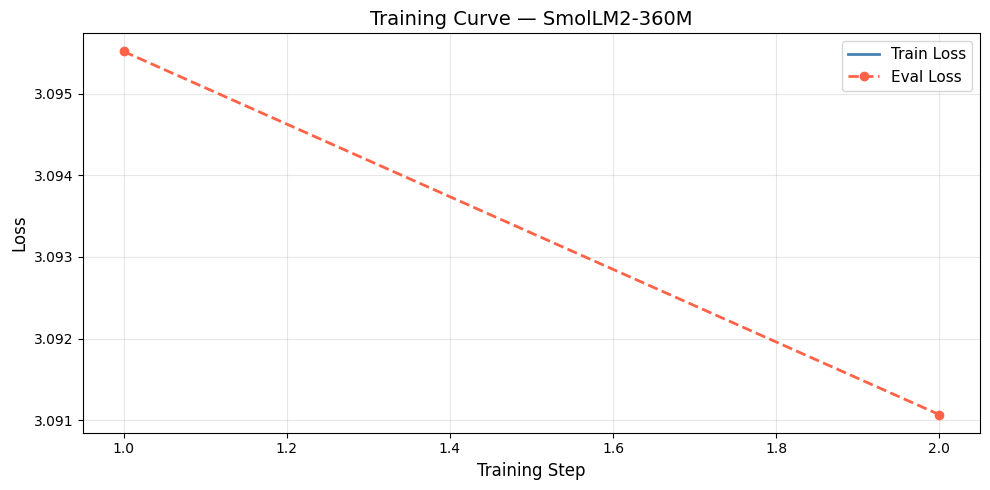

Grafik disimpan sebagai 'training_curve.png'


In [ ]:
import matplotlib.pyplot as plt

# Ambil log history dari trainer
log_history  = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
if eval_losses:
    ax.plot(eval_steps, eval_losses, label="Eval Loss", color="tomato",
            linestyle="--", marker="o", linewidth=2)
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"Training Curve — {MODEL_ID.split('/')[-1]}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan sebagai 'training_curve.png'")

## 9. (Opsional) Merge LoRA ke Base Model

Jika ingin menyimpan model lengkap (tanpa adapter terpisah) untuk deployment:

In [ ]:
# Merge adapter ke dalam bobot base model
# Catatan: membutuhkan RAM/VRAM lebih besar

MERGE_MODEL = False  # Ubah ke True jika ingin merge

if MERGE_MODEL:
    print("Merge adapter ke base model...")
    merged = finetuned_model.merge_and_unload()
    os.makedirs(MERGED_DIR, exist_ok=True)
    merged.save_pretrained(MERGED_DIR)
    tokenizer.save_pretrained(MERGED_DIR)
    print(f"Model merged disimpan di: {MERGED_DIR}")
else:
    print("Skip merge. Gunakan adapter terpisah saat inference.")
    print("Untuk load saat inference:")
    print("  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)")
    print(f"  model = PeftModel.from_pretrained(base, '{ADAPTER_DIR}')")

Skip merge. Gunakan adapter terpisah saat inference.
Untuk load saat inference:
  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)
  model = PeftModel.from_pretrained(base, './output/adapter')
